# 模糊综合评价 -- 公司综合实力评价

## 项目概述

本notebook对 **a, b, c, d, e, f, g** 七家公司进行模糊综合评价(Fuzzy Comprehensive Evaluation, FCE),
评价其综合实力并进行排序.

### 评价指标体系(三层结构)

- **目标层(A)**: 公司综合实力
- **准则层(B)**: 3个一级指标
  - **B1 产品综合评价**: C1~C7(7个二级指标)
  - **B2 成本费用**: C8~C15(8个二级指标)
  - **B3 销售能力**: C16~C19(4个二级指标)
- **指标层(C)**: 19个二级指标

### 隶属函数类型(基于梯形模糊分布, 源自图二)

| 类型 | 适用场景 | 梯形函数特征 |
|------|---------|-------------|
| 偏大型 | 效益型指标(越大越好) | 升半梯形 |
| 偏小型 | 成本型指标(越小越好) | 降半梯形 |
| 中间型 | 适度型指标(在最优区间最好) | 全梯形 |

### 评价等级

V = {v1优秀, v2良好, v3中等, v4较差, v5很差}, 对应分值 S = [100, 80, 60, 40, 20]

### 代码模块

1. **模块1: 数据处理** -- 读取Excel, 隶属函数计算, 隶属度矩阵构建
2. **模块2: 权重确定** -- AHP层次分析法, 判断矩阵, 一致性检验, 多层权重合成
3. **模块3: 模糊综合评价** -- 两级模糊合成, 综合得分计算与排序
4. **模块4: 结果可视化** -- 柱状图, 堆叠图, 雷达图, 分组对比图


In [6]:
# ============================================================
# 导入所需库
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# ---------- 设置中文字体(解决matplotlib中文显示问题) ----------
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# ---------- 设置pandas显示选项 ----------
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)
pd.set_option('display.unicode.ambiguous_as_wide', True)
pd.set_option('display.unicode.east_asian_width', True)

print("所有库导入成功!")
print(f"NumPy版本: {np.__version__}")
print(f"Pandas版本: {pd.__version__}")


所有库导入成功!
NumPy版本: 1.23.5
Pandas版本: 1.5.3


---
## 模块1: 数据处理

### 功能说明
1. 读取 `company_data.xlsx` 中的原始数据(7家公司 x 19个指标)
2. 定义三种梯形隶属函数(偏大型/偏小型/中间型, 源自图二)
3. 为每个指标的5个评价等级设定隶属函数参数
4. 计算每个指标对各等级的隶属度, 构建隶属度矩阵 R


In [7]:
# ============================================================
# 模块1: 数据处理
# ============================================================

# ----------------------------------------------------------
# 1.1 读取Excel数据
# ----------------------------------------------------------
data_file = 'company_data.xlsx'

# 读取原始数据(仅数值的sheet)
df_raw = pd.read_excel(data_file, sheet_name='数据(仅数值)', index_col=0)
# 读取指标体系(含类型信息)
df_meta = pd.read_excel(data_file, sheet_name='指标体系')

print("=" * 60)
print("  原始数据(7家公司 x 19个指标)")
print("=" * 60)
print(df_raw.to_string())
print(f"\n数据形状: {df_raw.shape[0]}个指标 x {df_raw.shape[1]}家公司")

# ---------- 提取指标类型信息 ----------
indicator_types = dict(zip(df_meta['二级指标'], df_meta['指标类型']))
print("\n指标类型分布:")
for itype in ['偏大型', '偏小型', '中间型']:
    count = sum(1 for v in indicator_types.values() if v == itype)
    names = [k for k, v in indicator_types.items() if v == itype]
    print(f"  {itype} ({count}个): {names}")

# 公司列表和指标列表
companies = df_raw.columns.tolist()      # ['a', 'b', 'c', 'd', 'e', 'f', 'g']
indicators = df_raw.index.tolist()       # ['C1_产品品牌', ..., 'C19_家庭需求']

# ----------------------------------------------------------
# 1.2 定义梯形隶属函数(基于图二的梯形型)
# ----------------------------------------------------------
def trapezoid_up(x, a, b, c, d):
    """偏大型升半梯形隶属函数(越大越优)

    参数 a < b < c < d, 其中 c=d 时退化为升半梯形:
    mu = 0       (x <= a)
    mu = (x-a)/(b-a)  (a < x <= b)
    mu = 1       (b < x <= c)
    mu = (d-x)/(d-c)  (c < x <= d)
    mu = 0       (x > d)
    """
    if x <= a:
        return 0.0
    elif x <= b:
        return (x - a) / (b - a)
    elif x <= c:
        return 1.0
    elif x <= d:
        return (d - x) / (d - c)
    else:
        return 0.0


def trapezoid_down(x, a, b, c, d):
    """偏小型降半梯形隶属函数(越小越优)

    参数 a < b < c < d, 其中 a=b 时退化为降半梯形:
    mu = 1       (x <= a)
    mu = (b-x)/(b-a)  (a < x <= b)
    mu = 0       (b < x <= c)
    mu = (x-c)/(d-c)  (c < x <= d)
    mu = 0       (x > d)
    """
    if x <= a:
        return 1.0
    elif x <= b:
        return (b - x) / (b - a)
    elif x <= c:
        return 0.0
    elif x <= d:
        return (x - c) / (d - c)
    else:
        return 0.0


def trapezoid_mid(x, a, b, c, d):
    """中间型梯形隶属函数(在区间[b, c]内最优)

    参数 a < b < c < d:
    mu = 0       (x <= a)
    mu = (x-a)/(b-a)  (a < x <= b)
    mu = 1       (b < x <= c)
    mu = (d-x)/(d-c)  (c < x <= d)
    mu = 0       (x > d)
    """
    if x <= a:
        return 0.0
    elif x <= b:
        return (x - a) / (b - a)
    elif x <= c:
        return 1.0
    elif x <= d:
        return (d - x) / (d - c)
    else:
        return 0.0


print("\n隶属函数定义完成!(梯形模糊分布)")
print("  偏大型: 升半梯形 - 值越大隶属度越高")
print("  偏小型: 降半梯形 - 值越小隶属度越高")
print("  中间型: 全梯形   - 在最优区间内隶属度最高")

# ----------------------------------------------------------
# 1.3 定义5个评价等级的隶属函数参数
# ----------------------------------------------------------
# 评价等级: v1优秀, v2良好, v3中等, v4较差, v5很差
# 所有指标值归一化到 0-100 分制

# --- 偏大型指标各等级的梯形参数 [a, b, c, d] ---
# 越大的值对应越高的等级
GRADE_PARAMS_UP = {
    'v1_优秀': (80, 90, 100, 100),
    'v2_良好': (70, 80, 80, 90),
    'v3_中等': (60, 70, 70, 80),
    'v4_较差': (50, 60, 60, 70),
    'v5_很差': (0,   0,  50, 60),
}

# --- 偏小型指标各等级的梯形参数 [a, b, c, d] ---
# 越小的值对应越高的等级(成本类指标)
GRADE_PARAMS_DOWN = {
    'v1_优秀': (0,   0,  15, 25),
    'v2_良好': (15, 25, 25, 35),
    'v3_中等': (25, 35, 35, 45),
    'v4_较差': (35, 45, 45, 55),
    'v5_很差': (45, 55, 100, 100),
}

# --- 中间型指标各等级的梯形参数 [a, b, c, d] ---
# 值在中间区间最好
GRADE_PARAMS_MID = {
    'v1_优秀': (65, 75, 85, 95),
    'v2_良好': (55, 65, 65, 75),
    'v3_中等': (45, 55, 55, 65),
    'v4_较差': (35, 45, 45, 55),
    'v5_很差': (0,   0,  35, 45),
}

# 等级名称
GRADE_NAMES = ['优秀', '良好', '中等', '较差', '很差']
GRADE_KEYS   = ['v1_优秀', 'v2_良好', 'v3_中等', 'v4_较差', 'v5_很差']

print("\n评价等级参数定义完成!")

# ----------------------------------------------------------
# 1.4 计算隶属度矩阵
# ----------------------------------------------------------
def calc_membership(value, itype):
    """计算单个指标值对5个评价等级的隶属度向量

    参数:
        value (float): 指标原始值
        itype (str)  : 指标类型('偏大型' / '偏小型' / '中间型')

    返回:
        np.ndarray: 长度为5的隶属度向量 [mu1, mu2, mu3, mu4, mu5]
    """
    # 选择隶属函数和参数
    if itype == '偏大型':
        func = trapezoid_up
        params = GRADE_PARAMS_UP
    elif itype == '偏小型':
        func = trapezoid_down
        params = GRADE_PARAMS_DOWN
    else:  # 中间型
        func = trapezoid_mid
        params = GRADE_PARAMS_MID

    result = []
    for gk in GRADE_KEYS:
        a, b, c, d = params[gk]
        mu = func(value, a, b, c, d)
        result.append(mu)

    return np.array(result)


# 构建所有指标的隶属度矩阵
# 结构: R_matrices[company][indicator] = np.array([mu1,...,mu5])
R_matrices = {}
for comp in companies:
    R_matrices[comp] = {}
    for ind in indicators:
        value = df_raw.loc[ind, comp]
        itype = indicator_types[ind]
        R_matrices[comp][ind] = calc_membership(value, itype)

print("\n隶属度矩阵计算完成! 共计算了", len(companies) * len(indicators), "个隶属度向量")

# ---------- 示例: 展示隶属度计算过程 ----------
demo_comp = 'a'
demo_ind = 'C2_产品质量'
demo_val = df_raw.loc[demo_ind, demo_comp]
demo_type = indicator_types[demo_ind]
demo_mu = R_matrices[demo_comp][demo_ind]
print(f"\n[隶属度计算示例]")
print(f"  公司: {demo_comp}  |  指标: {demo_ind}")
print(f"  原始值: {demo_val}  |  指标类型: {demo_type}")
print(f"  隶属度向量: [{', '.join(f'{v:.4f}' for v in demo_mu)}]")
print(f"  -> 最大隶属等级: {GRADE_NAMES[np.argmax(demo_mu)]}")

# ---------- 展示完整隶属度矩阵(公司a为例) ----------
print(f"\n公司a的完整隶属度矩阵 R_a (19x5):")
R_demo = np.array([R_matrices['a'][ind] for ind in indicators])
df_R = pd.DataFrame(R_demo, index=indicators, columns=GRADE_NAMES)
print(df_R.round(3).to_string())


  原始数据(7家公司 x 19个指标)
                      a     b     c      d     e     f     g
指标                                                        
C1_产品品牌        81.0  82.3  66.7   89.8  77.8  88.6  88.4
C2_产品质量        94.7  88.6  77.8  100.0  87.9  79.4  83.2
C3_性价比          87.0  76.6  73.0   84.4  85.3  75.6  70.7
C4_产品款式        89.1  71.7  74.4   81.2  75.1  62.3  68.8
C5_产品包装        65.3  68.4  77.2   80.8  69.3  73.1  76.7
C6_店铺信用度     100.0  76.5  84.6   92.6  81.6  72.1  77.8
C7_售后服务        86.9  78.8  81.1   93.2  78.1  73.7  70.9
C8_材料费          21.8  21.8  27.3    8.6  38.4  37.9  38.1
C9_运输费用        13.2  15.1  18.3    6.2  24.5  27.8  27.7
C10_设备维修费用    8.6   5.1  12.6    6.5  16.7  19.0  22.0
C11_运行费用        7.8  18.8  16.1   13.2  23.8  26.7  28.2
C12_设备折旧费用   15.7   8.1  19.8    6.2  19.0  23.9  17.5
C13_人员工资       25.8  27.5  26.8   18.3  33.9  30.1  40.0
C14_电耗费用        6.5   4.8  11.6    4.0  15.1  17.7  13.8
C15_水耗费用        5.1   6.3   9.4    0.6  10.7   9.1   8.2
C16_销售人

---
## 模块2: 权重确定(层次分析法 AHP)

### 方法说明
采用 **层次分析法(Analytic Hierarchy Process, AHP)** 确定各级指标权重:

1. **构造判断矩阵**: 两两比较指标相对重要性, 使用 **1-9标度法**
2. **计算权重向量**: 采用 **方根法(几何平均法)** 近似计算
3. **一致性检验**: 计算 CR = CI / RI, 要求 **CR < 0.1** 通过检验
4. **多层权重合成**: 综合权重 = 一级权重 x 二级权重

### 1-9标度含义
| 标度 | 含义 |
|------|------|
| 1 | 两因素同等重要 |
| 3 | 前者比后者稍微重要 |
| 5 | 前者比后者明显重要 |
| 7 | 前者比后者强烈重要 |
| 9 | 前者比后者极端重要 |
| 2,4,6,8 | 相邻判断的中间值 |
| 倒数 | 若因素i与j比较得a_ij, 则j与i比较得1/a_ij |


In [8]:
# ============================================================
# 模块2: 权重确定(AHP层次分析法)
# ============================================================

# ----------------------------------------------------------
# 2.1 AHP核心函数
# ----------------------------------------------------------
def ahp_weights(judgment_matrix, method='geometric_mean'):
    """AHP法计算权重向量并进行一致性检验

    参数:
        judgment_matrix (np.ndarray): 判断矩阵(正互反矩阵) n*n
        method (str): 'geometric_mean'(方根法) 或 'eigenvector'(特征向量法)

    返回:
        weights    (np.ndarray): 权重向量(归一化后)
        lambda_max (float)     : 最大特征值
        CR         (float)     : 一致性比率
    """
    n = judgment_matrix.shape[0]

    if method == 'geometric_mean':
        # ---------- 方根法(几何平均法) ----------
        # 步骤1: 计算每行元素的几何平均值
        geo_mean = np.power(np.prod(judgment_matrix, axis=1), 1.0 / n)
        # 步骤2: 归一化得到权重
        weights = geo_mean / np.sum(geo_mean)
        # 步骤3: 近似计算最大特征值
        Aw = judgment_matrix @ weights
        lambda_max = np.mean(Aw / weights)
    else:
        # ---------- 特征向量法 ----------
        eigenvalues, eigenvectors = np.linalg.eig(judgment_matrix)
        lambda_max = np.max(eigenvalues.real)
        max_idx = np.argmax(eigenvalues.real)
        weights = np.abs(eigenvectors[:, max_idx].real)
        weights = weights / np.sum(weights)

    # ---------- 一致性检验 ----------
    CI = (lambda_max - n) / (n - 1) if n > 1 else 0.0

    # Saaty 随机一致性指标 RI
    RI_table = {1: 0.00, 2: 0.00, 3: 0.58, 4: 0.90, 5: 1.12,
                6: 1.24, 7: 1.32, 8: 1.41, 9: 1.45, 10: 1.49}
    RI = RI_table.get(n, 1.5)

    CR = CI / RI if RI > 0 else 0.0

    return weights, lambda_max, CR


def print_ahp_result(name, judgment_matrix, labels, weights, lambda_max, CR):
    """格式化打印AHP计算结果"""
    n = len(weights)
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")

    # 打印判断矩阵
    print("判断矩阵:")
    df_j = pd.DataFrame(judgment_matrix, index=labels, columns=labels)
    print(df_j.to_string())

    # 打印权重
    print(f"\n权重向量({n}个指标):")
    for lb, w in zip(labels, weights):
        bar = '|' * int(w * 100)
        print(f"  {lb:20s}  {w:.4f}  ({w*100:5.2f}%)  {bar}")

    # 打印检验结果
    CI = (lambda_max - n) / (n - 1) if n > 1 else 0
    print(f"\n一致性检验:")
    print(f"  最大特征值 lambda_max = {lambda_max:.4f}")
    print(f"  一致性指标 CI = {CI:.4f}")
    print(f"  一致性比率 CR = {CR:.4f}")
    if CR < 0.1:
        print(f"  >>> CR < 0.1, 通过一致性检验! <<<")
    else:
        print(f"  >>> CR >= 0.1, 未通过一致性检验, 需调整判断矩阵! <<<")


# ----------------------------------------------------------
# 2.2 一级指标权重(B层对A层)
# ----------------------------------------------------------
# A-B判断矩阵: B1产品综合评价 vs B2成本费用 vs B3销售能力
# 产品综合评价最重要, 成本费用次之, 销售能力稍弱
A_B_matrix = np.array([
    [1,    2,    3   ],   # B1 vs [B1, B2, B3]
    [1/2,  1,    2   ],   # B2 vs [B1, B2, B3]
    [1/3,  1/2,  1   ],   # B3 vs [B1, B2, B3]
])
B_labels = ['B1_产品综合评价', 'B2_成本费用', 'B3_销售能力']

w_B, lam_B, cr_B = ahp_weights(A_B_matrix, method='geometric_mean')
print_ahp_result('一级指标(B层)权重 -- A-B判断矩阵',
                 A_B_matrix, B_labels, w_B, lam_B, cr_B)

# ----------------------------------------------------------
# 2.3 二级指标权重(C层对B层)
# ----------------------------------------------------------

# --- B1下二级指标: C1-C7(7个指标) ---
B1_C_matrix = np.array([
    [1,   1/3, 1/3, 1,   1,   1/2, 1/2],   # C1 产品品牌
    [3,   1,   1,   3,   3,   2,   2  ],   # C2 产品质量(最重要)
    [3,   1,   1,   3,   3,   2,   2  ],   # C3 性价比(最重要)
    [1,   1/3, 1/3, 1,   1,   1/2, 1/2],   # C4 产品款式
    [1,   1/3, 1/3, 1,   1,   1/2, 1/2],   # C5 产品包装
    [2,   1/2, 1/2, 2,   2,   1,   1  ],   # C6 店铺信用度
    [2,   1/2, 1/2, 2,   2,   1,   1  ],   # C7 售后服务
])
C1_labels = ['C1_产品品牌', 'C2_产品质量', 'C3_性价比', 'C4_产品款式',
             'C5_产品包装', 'C6_店铺信用度', 'C7_售后服务']

w_C1, lam_C1, cr_C1 = ahp_weights(B1_C_matrix, method='geometric_mean')
print_ahp_result('B1产品综合评价下二级指标 -- B1-C判断矩阵',
                 B1_C_matrix, C1_labels, w_C1, lam_C1, cr_C1)

# --- B2下二级指标: C8-C15(8个指标) ---
B2_C_matrix = np.array([
    [1,   2,   2,   2,   2,   3,   4,   4  ],   # C8 材料费
    [1/2, 1,   1,   1,   1,   2,   3,   3  ],   # C9 运输费用
    [1/2, 1,   1,   1,   1,   2,   3,   3  ],   # C10 设备维修费用
    [1/2, 1,   1,   1,   1,   2,   3,   3  ],   # C11 运行费用
    [1/2, 1,   1,   1,   1,   2,   3,   3  ],   # C12 设备折旧费用
    [1/3, 1/2, 1/2, 1/2, 1/2, 1,   2,   2  ],   # C13 人员工资
    [1/4, 1/3, 1/3, 1/3, 1/3, 1/2, 1,   1  ],   # C14 电耗费用
    [1/4, 1/3, 1/3, 1/3, 1/3, 1/2, 1,   1  ],   # C15 水耗费用
])
C2_labels = ['C8_材料费', 'C9_运输费用', 'C10_设备维修费用', 'C11_运行费用',
             'C12_设备折旧费用', 'C13_人员工资', 'C14_电耗费用', 'C15_水耗费用']

w_C2, lam_C2, cr_C2 = ahp_weights(B2_C_matrix, method='geometric_mean')
print_ahp_result('B2成本费用下二级指标 -- B2-C判断矩阵',
                 B2_C_matrix, C2_labels, w_C2, lam_C2, cr_C2)

# --- B3下二级指标: C16-C19(4个指标) ---
B3_C_matrix = np.array([
    [1,   3,   2,   2  ],   # C16 销售人员能力(最重要)
    [1/3, 1,   1/2, 1/2],   # C17 广告宣传
    [1/2, 2,   1,   1  ],   # C18 行业需求
    [1/2, 2,   1,   1  ],   # C19 家庭需求
])
C3_labels = ['C16_销售人员能力', 'C17_广告宣传', 'C18_行业需求', 'C19_家庭需求']

w_C3, lam_C3, cr_C3 = ahp_weights(B3_C_matrix, method='geometric_mean')
print_ahp_result('B3销售能力下二级指标 -- B3-C判断矩阵',
                 B3_C_matrix, C3_labels, w_C3, lam_C3, cr_C3)

# ----------------------------------------------------------
# 2.4 多层权重合成(19个二级指标的综合权重)
# ----------------------------------------------------------
# 综合权重 = B层权重 * C层对应权重, 然后归一化
combined_weights = np.concatenate([
    w_B[0] * w_C1,   # B1下的7个指标
    w_B[1] * w_C2,   # B2下的8个指标
    w_B[2] * w_C3,   # B3下的4个指标
])
combined_weights = combined_weights / np.sum(combined_weights)

print("\n" + "=" * 60)
print("  综合权重汇总(19个二级指标)")
print("=" * 60)

df_weights = pd.DataFrame({
    '指标': indicators,
    '类型': [indicator_types[ind] for ind in indicators],
    '所属B层': (['B1'] * 7 + ['B2'] * 8 + ['B3'] * 4),
    'C层权重': np.round(np.concatenate([w_C1, w_C2, w_C3]), 4),
    '综合权重': np.round(combined_weights, 4),
    '综合权重%': np.round(combined_weights * 100, 2)
})
# 按综合权重降序排列
df_weights = df_weights.sort_values('综合权重', ascending=False).reset_index(drop=True)
print(df_weights.to_string())

print(f"\n综合权重总和: {combined_weights.sum():.6f}")
print(f"权重最大的3个指标: {df_weights['指标'].iloc[0]}, {df_weights['指标'].iloc[1]}, {df_weights['指标'].iloc[2]}")



  一级指标(B层)权重 -- A-B判断矩阵
判断矩阵:
                 B1_产品综合评价  B2_成本费用  B3_销售能力
B1_产品综合评价         1.000000          2.0          3.0
B2_成本费用             0.500000          1.0          2.0
B3_销售能力             0.333333          0.5          1.0

权重向量(3个指标):
  B1_产品综合评价             0.5396  (53.96%)  |||||||||||||||||||||||||||||||||||||||||||||||||||||
  B2_成本费用               0.2970  (29.70%)  |||||||||||||||||||||||||||||
  B3_销售能力               0.1634  (16.34%)  ||||||||||||||||

一致性检验:
  最大特征值 lambda_max = 3.0092
  一致性指标 CI = 0.0046
  一致性比率 CR = 0.0079
  >>> CR < 0.1, 通过一致性检验! <<<

  B1产品综合评价下二级指标 -- B1-C判断矩阵
判断矩阵:
               C1_产品品牌  C2_产品质量  C3_性价比  C4_产品款式  C5_产品包装  C6_店铺信用度  C7_售后服务
C1_产品品牌            1.0     0.333333   0.333333          1.0          1.0            0.5          0.5
C2_产品质量            3.0     1.000000   1.000000          3.0          3.0            2.0          2.0
C3_性价比              3.0     1.000000   1.000000          3.0          3.0            2.0          2.0


---
## 模块3: 模糊综合评价

### 模糊合成算子: M(.,+) 加权平均型

模糊综合评价采用两级合成:

1. **一级模糊评价(C层 -> B层)**:
   对每个一级指标 Bi, 用其下二级指标的隶属度矩阵 R_Bi 和权重向量 W_Bi 合成:
   $$B_i = W_{Bi} \cdot R_{Bi} \quad (1 \times k \cdot k \times 5 = 1 \times 5)$$

2. **二级模糊评价(B层 -> A层)**:
   将所有一级评价结果组合, 与一级权重合成:
   $$B = W_B \cdot R_{total} \quad (1 \times 3 \cdot 3 \times 5 = 1 \times 5)$$

3. **综合得分**: $$Score = B \cdot S^T$$
   其中 S = [100, 80, 60, 40, 20] 为各等级代表分数

4. **排序**: 按综合得分从高到低对公司进行排序


In [9]:
# ============================================================
# 模块3: 模糊综合评价
# ============================================================

# ----------------------------------------------------------
# 3.1 按一级指标分组(定义指标索引范围)
# ----------------------------------------------------------
B_groups = {
    'B1_产品综合评价': {
        'indices': list(range(0, 7)),      # C1-C7
        'C_labels': C1_labels,
        'w_C': w_C1
    },
    'B2_成本费用': {
        'indices': list(range(7, 15)),     # C8-C15
        'C_labels': C2_labels,
        'w_C': w_C2
    },
    'B3_销售能力': {
        'indices': list(range(15, 19)),    # C16-C19
        'C_labels': C3_labels,
        'w_C': w_C3
    },
}

# ----------------------------------------------------------
# 3.2 一级模糊评价(C层 -> B层)
# ----------------------------------------------------------
# 对每个公司, 对每个一级指标Bi, 进行加权平均合成
B_results = {}  # {company: {B_name: np.array([5])}}

print("=" * 60)
print("  一级模糊评价结果(C层 -> B层)")
print("=" * 60)

for comp in companies:
    B_results[comp] = {}
    print(f"\n--- 公司 {comp} ---")
    for b_name, b_info in B_groups.items():
        idxs = b_info['indices']
        w_b = b_info['w_C']

        # 构建该一级指标下的隶属度矩阵 R_Bi (k行 x 5列, k为该组二级指标个数)
        R_bi = np.array([R_matrices[comp][indicators[i]] for i in idxs])

        # M(.,+) 加权平均型模糊合成: B_i = W_Bi @ R_Bi
        B_i = w_b @ R_bi  # (1*k) @ (k*5) = (1*5)

        # 归一化(确保向量和为1)
        if B_i.sum() > 0:
            B_i = B_i / B_i.sum()

        B_results[comp][b_name] = B_i

        best_grade = GRADE_NAMES[np.argmax(B_i)]
        print(f"  {b_name}: [{', '.join(f'{v:.3f}' for v in B_i)}] -> {best_grade}")

# ----------------------------------------------------------
# 3.3 二级模糊评价(B层 -> A层) + 综合得分
# ----------------------------------------------------------
print("\n" + "=" * 60)
print("  二级模糊综合评价结果(最终评价)")
print("=" * 60)

S = np.array([100, 80, 60, 40, 20])  # 等级分数向量
final_results = {}  # {company: {'B': np.array, 'score': float}}

for comp in companies:
    # 构造总评价矩阵 R_total (3*5)
    R_total = np.array([
        B_results[comp]['B1_产品综合评价'],
        B_results[comp]['B2_成本费用'],
        B_results[comp]['B3_销售能力'],
    ])

    # 二级模糊合成 B = W_B @ R_total
    B_final = w_B @ R_total  # (1*3) @ (3*5) = (1*5)

    if B_final.sum() > 0:
        B_final = B_final / B_final.sum()

    # 综合得分(加权平均)
    score = B_final @ S

    final_results[comp] = {'B': B_final, 'score': score}

    best_grade = GRADE_NAMES[np.argmax(B_final)]
    print(f"\n公司 {comp}:")
    print(f"  最终评价向量: [{', '.join(f'{v:.4f}' for v in B_final)}]")
    print(f"  最大隶属等级: {best_grade} (隶属度 {B_final.max():.4f})")
    print(f"  综合得分: {score:.2f} 分")

# ----------------------------------------------------------
# 3.4 公司综合排序
# ----------------------------------------------------------
print("\n" + "=" * 60)
print("  公司综合实力最终排序")
print("=" * 60)

ranking = sorted(final_results.items(), key=lambda x: x[1]['score'], reverse=True)

print(f"\n{'排名':<6}{'公司':<8}{'综合得分':<12}{'评价等级':<10}{'评价向量'}")
print("-" * 80)
for rank, (comp, result) in enumerate(ranking, 1):
    B_vec = result['B']
    best_grade = GRADE_NAMES[np.argmax(B_vec)]
    vec_str = f"[{', '.join(f'{v:.3f}' for v in B_vec)}]"
    print(f"{rank:<6}{comp:<8}{result['score']:<12.2f}{best_grade:<10}{vec_str}")

# 打包排序结果供可视化使用
sorted_companies = [comp for comp, _ in ranking]
sorted_scores = [result['score'] for _, result in ranking]


  一级模糊评价结果(C层 -> B层)

--- 公司 a ---
  B1_产品综合评价: [0.802, 0.198, 0.000, 0.000, 0.000] -> 优秀
  B2_成本费用: [0.046, 0.190, 0.253, 0.255, 0.255] -> 较差
  B3_销售能力: [0.000, 0.480, 0.520, 0.000, 0.000] -> 中等

--- 公司 b ---
  B1_产品综合评价: [0.314, 0.474, 0.212, 0.000, 0.000] -> 良好
  B2_成本费用: [0.058, 0.182, 0.250, 0.255, 0.255] -> 较差
  B3_销售能力: [0.000, 0.100, 0.663, 0.237, 0.000] -> 中等

--- 公司 c ---
  B1_产品综合评价: [0.168, 0.562, 0.269, 0.000, 0.000] -> 良好
  B2_成本费用: [0.036, 0.166, 0.253, 0.272, 0.272] -> 较差
  B3_销售能力: [0.499, 0.459, 0.042, 0.000, 0.000] -> 优秀

--- 公司 d ---
  B1_产品综合评价: [0.787, 0.213, 0.000, 0.000, 0.000] -> 优秀
  B2_成本费用: [0.007, 0.243, 0.250, 0.250, 0.250] -> 中等
  B3_销售能力: [0.478, 0.506, 0.016, 0.000, 0.000] -> 良好

--- 公司 e ---
  B1_产品综合评价: [0.456, 0.480, 0.064, 0.000, 0.000] -> 良好
  B2_成本费用: [0.101, 0.116, 0.223, 0.268, 0.292] -> 很差
  B3_销售能力: [0.000, 0.041, 0.503, 0.456, 0.000] -> 中等

--- 公司 f ---
  B1_产品综合评价: [0.113, 0.479, 0.349, 0.060, 0.000] -> 良好
  B2_成本费用: [0.063, 0.093, 0.229, 0.

---
## 模块4: 结果可视化

### 生成图表
1. **综合得分柱状图** -- 直观对比7家公司最终得分及等级划分
2. **评价等级隶属度堆叠图** -- 展示每家公司对各等级的隶属度分布
3. **一级指标雷达图** -- 展示各公司在产品, 成本, 销售三维度的表现
4. **一级指标分组柱状图** -- 对比各公司在不同维度上的得分
5. **综合权重分布图** -- 展示19个指标的综合权重排序


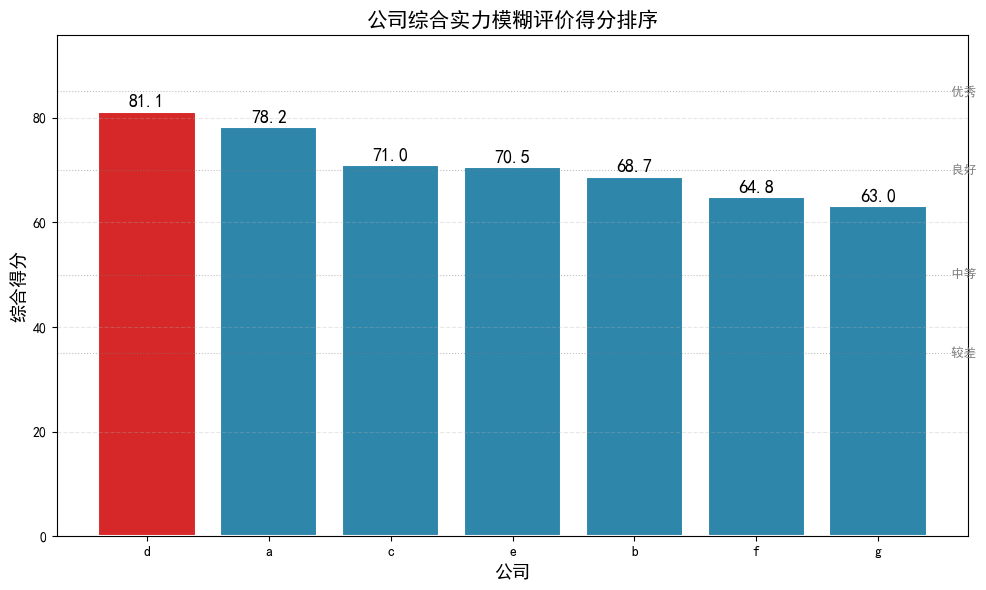

图1 完成: score_ranking.png


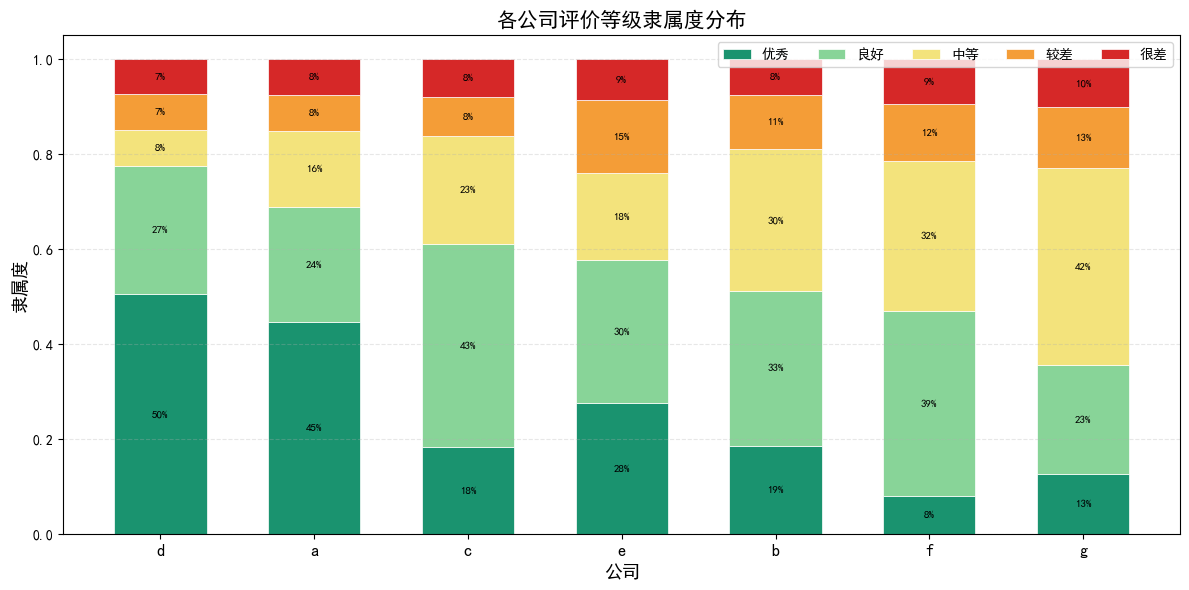

图2 完成: grade_distribution.png


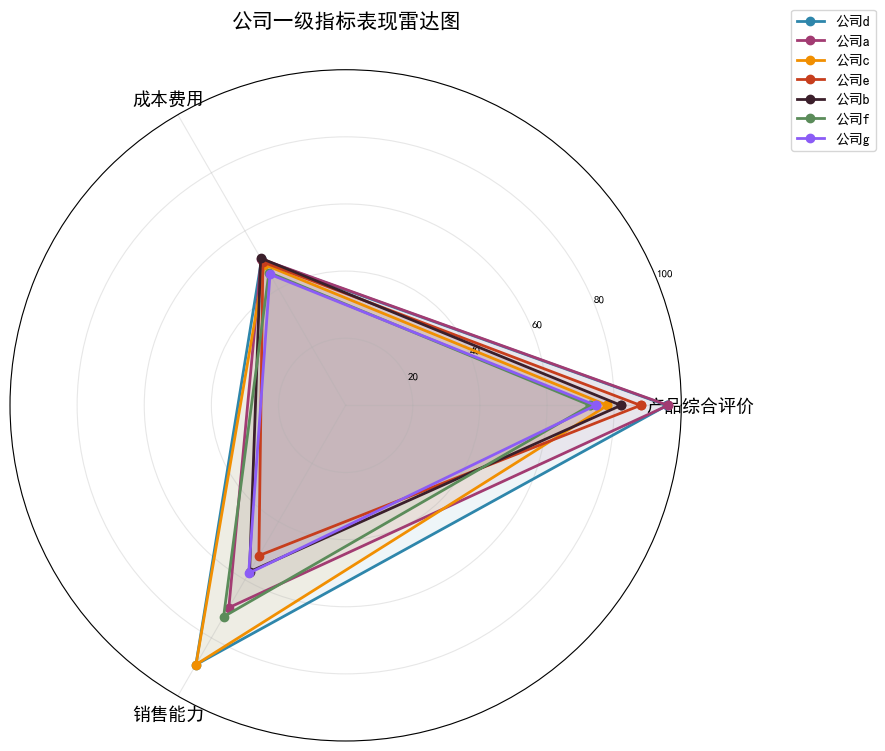

图3 完成: radar_chart.png


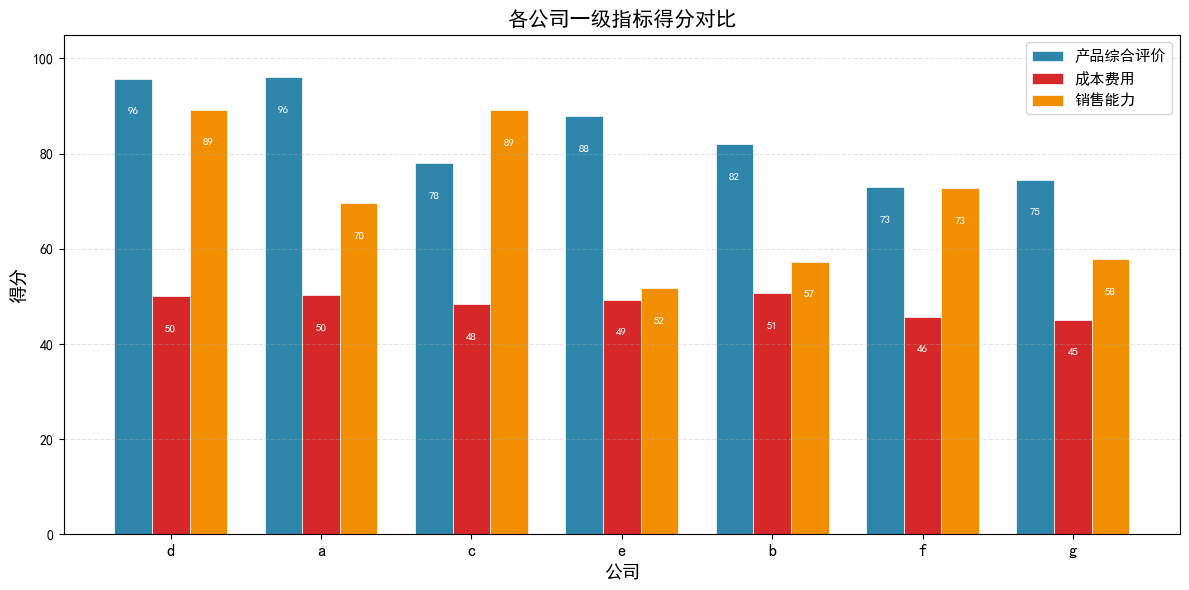

图4 完成: dimension_comparison.png


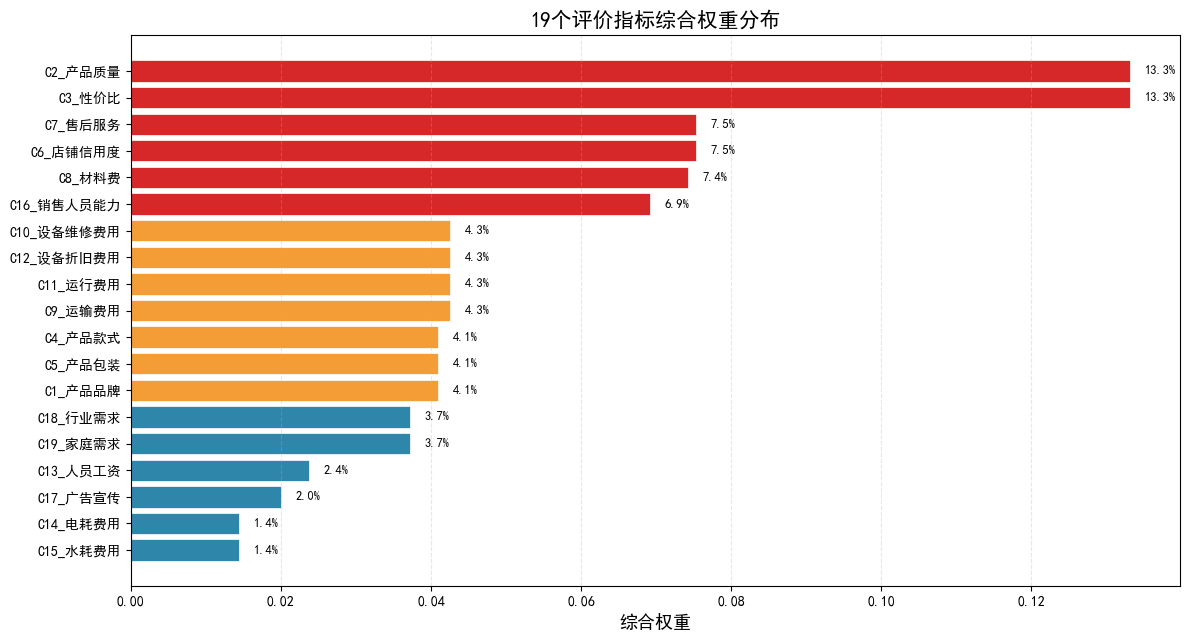

图5 完成: weight_distribution.png

  全部可视化完成! 共生成5张图表.


In [10]:
# ============================================================
# 模块4: 结果可视化
# ============================================================

# ---------- 准备一级指标得分数据 ----------
b_scores = {}
for comp in companies:
    b_scores[comp] = []
    for b_name in ['B1_产品综合评价', 'B2_成本费用', 'B3_销售能力']:
        score_bi = B_results[comp][b_name] @ np.array([100, 80, 60, 40, 20])
        b_scores[comp].append(score_bi)

# ---------- 颜色方案 ----------
COMPANY_COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#5B8C5A', '#8B5CF6']
GRADE_COLORS = ['#1A936F', '#88D498', '#F3E37C', '#F49D37', '#D62828']
B_COLORS = ['#2E86AB', '#D62828', '#F18F01']

# ----------------------------------------------------------
# 图1: 综合得分柱状图(带等级分界线)
# ----------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(10, 6))

max_score = max(sorted_scores)
bar_colors = ['#D62828' if s == max_score else '#2E86AB' for s in sorted_scores]

bars = ax1.bar(sorted_companies, sorted_scores, color=bar_colors,
               edgecolor='white', linewidth=1.5)

# 数值标注
for bar, score in zip(bars, sorted_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{score:.1f}', ha='center', va='bottom', fontsize=13, fontweight='bold')

# 等级分界线
for level, th in [('优秀', 85), ('良好', 70), ('中等', 50), ('较差', 35)]:
    ax1.axhline(y=th, color='gray', linestyle=':', alpha=0.5, linewidth=0.8)
    ax1.text(6.55, th, f' {level}', fontsize=9, color='gray', va='center')

ax1.set_xlabel('公司', fontsize=13)
ax1.set_ylabel('综合得分', fontsize=13)
ax1.set_title('公司综合实力模糊评价得分排序', fontsize=15, fontweight='bold')
ax1.set_ylim(0, max_score * 1.18)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('score_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print("图1 完成: score_ranking.png")

# ----------------------------------------------------------
# 图2: 评价等级隶属度堆叠柱状图
# ----------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(12, 6))

x = np.arange(len(sorted_companies))
width = 0.6
bottom = np.zeros(len(sorted_companies))

for i, (grade_name, color) in enumerate(zip(GRADE_NAMES, GRADE_COLORS)):
    values = [final_results[comp]['B'][i] for comp in sorted_companies]
    bars = ax2.bar(x, values, width, bottom=bottom, label=grade_name,
                   color=color, edgecolor='white', linewidth=0.5)
    # 在每段中间标注百分比(仅当大于5%时)
    for j, (b, v) in enumerate(zip(bars, values)):
        if v > 0.05:
            ax2.text(b.get_x() + b.get_width()/2, bottom[j] + v/2,
                     f'{v*100:.0f}%', ha='center', va='center', fontsize=8, fontweight='bold')
    bottom += values

ax2.set_xlabel('公司', fontsize=13)
ax2.set_ylabel('隶属度', fontsize=13)
ax2.set_title('各公司评价等级隶属度分布', fontsize=15, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(sorted_companies, fontsize=12)
ax2.legend(loc='upper right', fontsize=10, ncol=5)
ax2.set_ylim(0, 1.05)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('grade_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("图2 完成: grade_distribution.png")

# ----------------------------------------------------------
# 图3: 一级指标雷达图
# ----------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

categories = ['产品综合评价', '成本费用', '销售能力']
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # 闭合

for i, comp in enumerate(sorted_companies):
    values = b_scores[comp] + b_scores[comp][:1]
    color = COMPANY_COLORS[i % len(COMPANY_COLORS)]
    ax3.fill(angles, values, alpha=0.08, color=color)
    ax3.plot(angles, values, 'o-', linewidth=2, label=f'公司{comp}', color=color, markersize=6)

ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(categories, fontsize=13, fontweight='bold')
ax3.set_ylim(0, 100)
ax3.set_yticks([20, 40, 60, 80, 100])
ax3.set_yticklabels(['20', '40', '60', '80', '100'], fontsize=8)
ax3.set_title('公司一级指标表现雷达图', fontsize=15, fontweight='bold', pad=30)
ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("图3 完成: radar_chart.png")

# ----------------------------------------------------------
# 图4: 一级指标分组柱状图
# ----------------------------------------------------------
fig4, ax4 = plt.subplots(figsize=(12, 6))

x = np.arange(len(sorted_companies))
width = 0.25
b_display = ['产品综合评价', '成本费用', '销售能力']

for i, (b_name, color) in enumerate(zip(
    ['B1_产品综合评价', 'B2_成本费用', 'B3_销售能力'], B_COLORS)):
    values = [b_scores[comp][i] for comp in sorted_companies]
    bars = ax4.bar(x + i * width, values, width, label=b_display[i],
                   color=color, edgecolor='white', linewidth=0.5)

    for bar, val in zip(bars, values):
        if val > 15:
            ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 6,
                     f'{val:.0f}', ha='center', va='top', fontsize=8,
                     color='white', fontweight='bold')

ax4.set_xlabel('公司', fontsize=13)
ax4.set_ylabel('得分', fontsize=13)
ax4.set_title('各公司一级指标得分对比', fontsize=15, fontweight='bold')
ax4.set_xticks(x + width)
ax4.set_xticklabels(sorted_companies, fontsize=12)
ax4.legend(fontsize=11)
ax4.set_ylim(0, 105)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('dimension_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("图4 完成: dimension_comparison.png")

# ----------------------------------------------------------
# 图5: 综合权重分布图(水平条形图)
# ----------------------------------------------------------
fig5, ax5 = plt.subplots(figsize=(12, 6.5))

# 按权重升序排列
w_sorted_idx = np.argsort(combined_weights)
w_sorted_inds = [indicators[i] for i in w_sorted_idx]
w_sorted_vals = combined_weights[w_sorted_idx]

# 颜色: 权重最高的用红色强调
w_colors = ['#D62828' if w > 0.06 else '#F49D37' if w > 0.04 else '#2E86AB'
            for w in w_sorted_vals]

bars = ax5.barh(range(len(w_sorted_vals)), w_sorted_vals, color=w_colors,
                edgecolor='white', linewidth=0.5)
ax5.set_yticks(range(len(w_sorted_vals)))
ax5.set_yticklabels(w_sorted_inds, fontsize=10)
ax5.set_xlabel('综合权重', fontsize=13)
ax5.set_title('19个评价指标综合权重分布', fontsize=15, fontweight='bold')
ax5.grid(axis='x', alpha=0.3, linestyle='--')

# 标注百分比
for i, (w, ind) in enumerate(zip(w_sorted_vals, w_sorted_inds)):
    ax5.text(w + 0.002, i, f'{w*100:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('weight_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("图5 完成: weight_distribution.png")

print("\n" + "=" * 60)
print("  全部可视化完成! 共生成5张图表.")
print("=" * 60)


---
## 总结

### 评价流程回顾

```
原始数据 (19指标 x 7公司)
    |
    +--> [模块1] 隶属函数计算 --> 隶属度矩阵 R (19x5 per company)
    |
    +--> [模块2] AHP权重确定 --> 综合权重 W (1x19)
    |         +-- 一级判断矩阵 (3x3)
    |         +-- 二级判断矩阵 (7x7, 8x8, 4x4)
    |         +-- 一致性检验 (CR < 0.1)
    |
    +--> [模块3] 模糊综合评价
    |         +-- 一级合成: B_i = W_Ci . R_Ci
    |         +-- 二级合成: B = W_B . R_total
    |         +-- 综合得分: Score = B . S'
    |
    +--> [模块4] 结果可视化
              +-- 综合得分柱状图
              +-- 等级隶属度堆叠图
              +-- 雷达图
              +-- 维度对比图
              +-- 权重分布图
```

### 方法优势
- **处理模糊性**: 隶属函数将精确值转化为模糊隶属度, 保留了过渡信息
- **多层权重**: AHP方法系统考虑了指标间的相对重要性
- **信息完整**: M(.,+)算子保留了全部权重和隶属度信息
- **可视化直观**: 多种图表从不同角度展示评价结果

### 生成文件清单
| 文件 | 说明 |
|------|------|
| `company_data.xlsx` | 原始数据(含指标体系说明) |
| `fuzzy_evaluation.ipynb` | 完整代码(本文件) |
| `score_ranking.png` | 综合得分排序图 |
| `grade_distribution.png` | 评价等级分布堆叠图 |
| `radar_chart.png` | 一级指标雷达图 |
| `dimension_comparison.png` | 一级指标分组对比图 |
| `weight_distribution.png` | 综合权重分布图 |
